# 05 — Multi-Objective Optimization (NSGA-II)

Surrogate-assisted multi-objective optimization using NSGA-II (pymoo).
Explores the Pareto front between configurable objectives (L/D vs mass, endurance vs manufacturability, etc.)
then validates the best candidates with AVL.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_all
from src.optimization.problem import run_nsga2_assisted, AVAILABLE_OBJECTIVES
from src.parameterization.design_variables import params_from_vector

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

from src.visualization.style import apply_style, COLORS
apply_style()

In [2]:
%load_ext autoreload
%autoreload 2

## 1. Configuration

Available objectives: L/D, structural mass, endurance, manufacturability, range, drag.

In [3]:
cfg = load_all()
mission = cfg['mission']
feasibility = cfg['feasibility']

print(f'Mission: V={mission.velocity} m/s, MTOW={mission.mtow} kg')
print(f'Mass budget: {mission.mass_budget:.3f} kg')
print(f'T_available @ cruise: {mission.thrust_available:.2f} N')

# Choose objectives (modify here to explore different trade-offs)
objectives = ("L_over_D", "struct_mass")

print(f'\nObjectives: {objectives}')
for obj in objectives:
    d = AVAILABLE_OBJECTIVES[obj]
    print(f'  {d["label"]:>25} ({d["sense"]}imize)')

print(f'\nAll available objectives:')
for name, d in AVAILABLE_OBJECTIVES.items():
    print(f'  {name:>15}: {d["label"]} ({d["sense"]})')
    
print(f'\nKey constraints:')
print(f'  SM range:            [{feasibility.sm_min:.0%}, {feasibility.sm_max:.0%}] MAC')
print(f'  T/D min:             {feasibility.td_min}')
print(f'  Endurance min:       {feasibility.endurance_min} s ({feasibility.endurance_min/60:.0f} min)')
print(f'  Vs max:              {feasibility.vs_max} m/s')
print(f'  Manuf min:           {feasibility.manufacturability_min}')

Mission: V=25.0 m/s, MTOW=2.5 kg
Mass budget: 1.692 kg
T_available @ cruise: 2.86 N

Objectives: ('L_over_D', 'struct_mass')
                        L/D (maximize)
       Structural mass [kg] (minimize)

All available objectives:
         L_over_D: L/D (max)
      struct_mass: Structural mass [kg] (min)
    endurance_min: Endurance [min] (max)
      manuf_score: Manufacturability (max)
         range_km: Range [km] (max)
       drag_force: Drag [N] (min)

Key constraints:
  SM range:            [-5%, 55%] MAC
  T/D min:             1.0
  Endurance min:       300.0 s (5 min)
  Vs max:              15.0 m/s
  Manuf min:           0.25


## 2. Run NSGA-II Multi-Objective Optimization

In [4]:
result = run_nsga2_assisted(
    mission=mission,
    feasibility=feasibility,
    surrogate_path='../models/surrogate_v2_ctrl',
    objectives=objectives,
    n_gen=50,       # moderate: avoid surrogate over-exploitation
    pop_size=50,
    n_validate=30,
    n_workers=8,
    seed=42,
    verbose=True,
)

=== NSGA-II Multi-Objective Optimization ===
Objectives (2): L/D, Structural mass [kg]
Population: 50, Generations: 50
AVL validation: 30 designs
Surrogate: 256-128-64, 5 ensemble

Phase 1: Running NSGA-II on surrogate...
  Surrogate Pareto: 3 designs in 15.3s
                          L/D: [15.230, 15.300]
         Structural mass [kg]: [0.638, 0.683]

Phase 2: Validating 3 Pareto + 10 enriched = 13 designs with AVL...
  [parallel mode: 8 workers, 13 designs]
  evaluated   10/13 (2.7/s, 10 feasible)
  evaluated   13/13 (3.4/s, 13 feasible)

=== Results ===
Pareto (surrogate): 3 designs
Validated (AVL):    13 designs
Feasible (AVL):     13

Best per objective (feasible):
         L_over_D: L/D=14.840, Structural mass [kg]=0.713
      struct_mass: L/D=14.226, Structural mass [kg]=0.658
             knee: L/D=14.406, Structural mass [kg]=0.666


## 3. Pareto Front Visualization

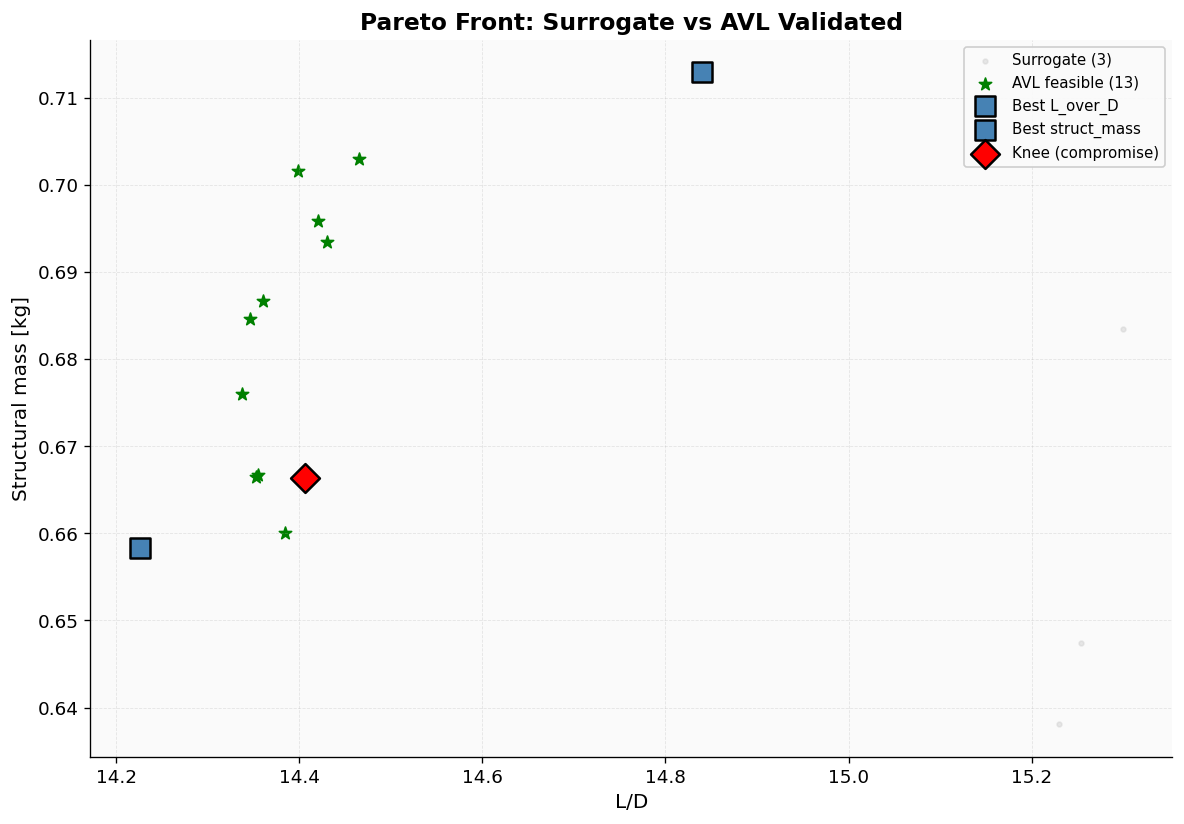

In [5]:
obj_defs = result['obj_defs']
pareto_F = result['pareto_F']
avl_F = result['avl_F']
avl_results = result['avl_results']
feasible_mask = result['avl_feasible_mask']
best = result['best_per_objective']

fig, ax = plt.subplots(figsize=(10, 7))

# Convert to display values (undo minimization sign flip)
def to_display(F, obj_defs):
    F_disp = F.copy()
    for i, d in enumerate(obj_defs):
        if d['sense'] == 'max':
            F_disp[:, i] = -F_disp[:, i]
    return F_disp

surr_disp = to_display(pareto_F, obj_defs)
avl_disp = to_display(avl_F, obj_defs)

# Surrogate Pareto (gray background)
ax.scatter(surr_disp[:, 0], surr_disp[:, 1], s=8, c='lightgray',
           alpha=0.5, label=f'Surrogate ({len(surr_disp)})')

# AVL validated — infeasible (orange)
infeas = ~feasible_mask
if infeas.any():
    ax.scatter(avl_disp[infeas, 0], avl_disp[infeas, 1], s=30,
               c='orange', alpha=0.6, label=f'AVL infeasible ({infeas.sum()})')

# AVL validated — feasible (green)
if feasible_mask.any():
    ax.scatter(avl_disp[feasible_mask, 0], avl_disp[feasible_mask, 1], s=60,
               c='green', marker='*', label=f'AVL feasible ({feasible_mask.sum()})')

# Best per objective + knee
markers = {'knee': ('D', 'red', 'Knee (compromise)')}
for obj_name in result['objectives']:
    markers[obj_name] = ('s', 'steelblue', f'Best {obj_name}')

for name, info in best.items():
    if name in markers:
        marker, color, label = markers[name]
        r = info['result']
        vals = [r.get(d['key'], 0) for d in obj_defs]
        ax.scatter(vals[0], vals[1], s=150, c=color, marker=marker,
                   edgecolors='black', linewidth=1.5, label=label, zorder=5)

ax.set_xlabel(obj_defs[0]['label'], fontsize=12)
ax.set_ylabel(obj_defs[1]['label'], fontsize=12)
ax.set_title('Pareto Front: Surrogate vs AVL Validated', fontsize=14)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/pareto_front.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Constraint Dashboard

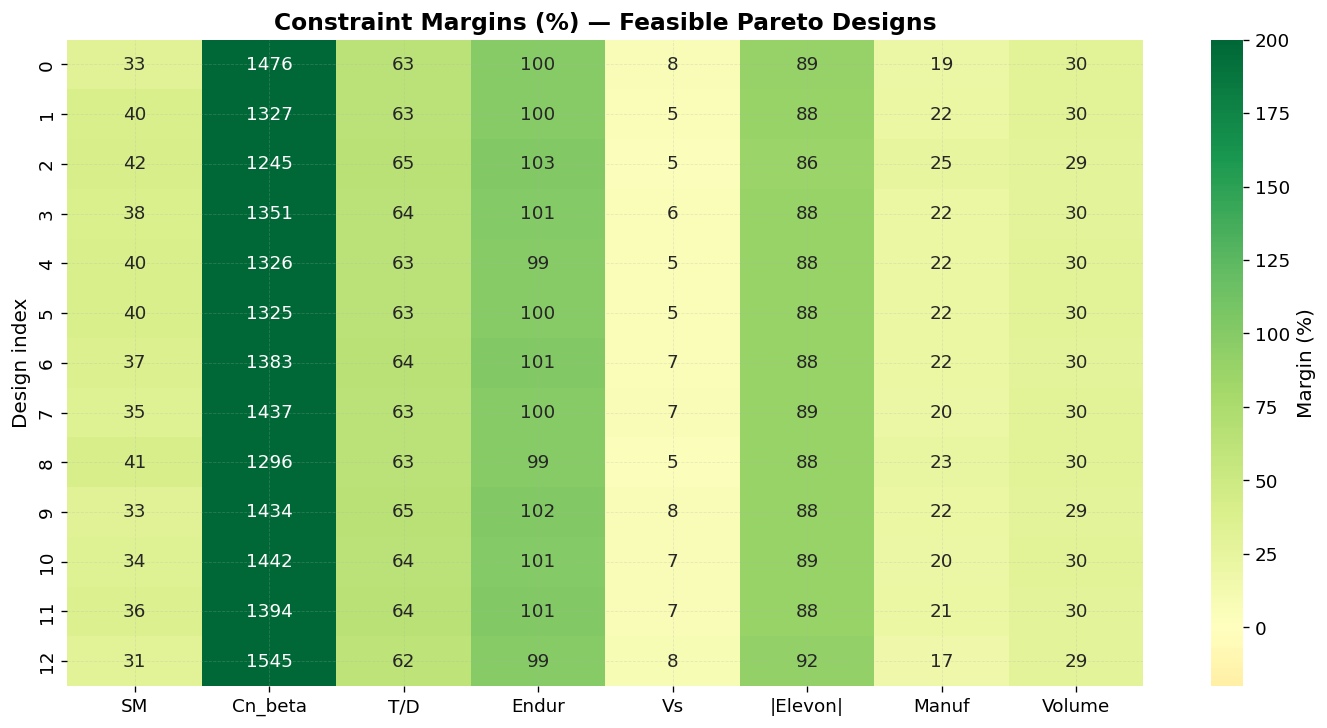

Tightest constraints across 13 feasible designs:
          SM: min margin = 31%
     Cn_beta: min margin = 1245%
         T/D: min margin = 62%
       Endur: min margin = 99%
          Vs: min margin = 5%
    |Elevon|: min margin = 86%
       Manuf: min margin = 17%
      Volume: min margin = 29%


In [6]:
# Constraint margins for all feasible designs
if result['n_feasible'] > 0:
    feas_results = [r for r in avl_results if r.get('is_feasible', False)]
    
    constraint_names = ['SM', 'Cn_beta', 'T/D', 'Endur', 'Vs', '|Elevon|', 'Manuf', 'Volume']
    
    margins = []
    for r in feas_results:
        row = [
            min(r['static_margin'] - feasibility.sm_min,
                feasibility.sm_max - r['static_margin']) / (feasibility.sm_max - feasibility.sm_min) * 100,
            (r['Cn_beta'] - feasibility.cn_beta_min) / max(abs(feasibility.cn_beta_min), 0.001) * 100,
            (r['T_over_D'] - feasibility.td_min) / max(abs(feasibility.td_min), 0.001) * 100,
            (r['endurance_s'] - feasibility.endurance_min) / max(abs(feasibility.endurance_min), 1) * 100,
            (feasibility.vs_max - r['Vs']) / max(abs(feasibility.vs_max), 0.001) * 100,
            (feasibility.elevon_deflection_max - abs(r['elevon_deflection'])) / feasibility.elevon_deflection_max * 100,
            (r['manufacturability_score'] - feasibility.manufacturability_min) / max(abs(feasibility.manufacturability_min), 0.001) * 100,
            (r['internal_volume'] - feasibility.volume_min) / max(abs(feasibility.volume_min), 0.001) * 100,
        ]
        margins.append(row)
    
    import pandas as pd
    df_margins = pd.DataFrame(margins, columns=constraint_names)
    
    fig, ax = plt.subplots(figsize=(12, max(4, len(feas_results) * 0.4 + 1)))
    sns.heatmap(df_margins, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
                ax=ax, cbar_kws={'label': 'Margin (%)'}, vmin=-20, vmax=200)
    ax.set_ylabel('Design index')
    ax.set_title('Constraint Margins (%) — Feasible Pareto Designs')
    plt.tight_layout()
    plt.savefig('../output/constraint_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Summary
    print(f'Tightest constraints across {len(feas_results)} feasible designs:')
    for col in constraint_names:
        min_margin = df_margins[col].min()
        print(f'  {col:>10}: min margin = {min_margin:.0f}%')
else:
    print('No feasible designs found — constraints too tight or surrogate gap too large')

## 5. Best Designs Summary & Save

In [7]:
import json
from pathlib import Path

out_dir = Path('../output')
out_dir.mkdir(exist_ok=True)

if result['n_feasible'] > 0:
    # Print best per objective
    print('=== Best Feasible Designs ===\n')
    header_parts = ['Design']
    for d in obj_defs:
        header_parts.append(d['label'][:12])
    header_parts.extend(['SM', 'Endur[min]', 'Manuf', 'Feasible'])
    print(f"{'  '.join(f'{h:>12}' for h in header_parts)}")
    print('-' * (14 * len(header_parts)))
    
    for name, info in best.items():
        r = info['result']
        parts = [f'{name:>12}']
        for d in obj_defs:
            parts.append(f'{r.get(d["key"], 0):>12.3f}')
        parts.append(f'{r.get("static_margin", 0):>12.3f}')
        parts.append(f'{r.get("endurance_min", 0):>12.1f}')
        parts.append(f'{r.get("manufacturability_score", 0):>12.3f}')
        parts.append(f'{"True" if r.get("is_feasible") else "False":>12}')
        print('  '.join(parts))
    
    # Save knee point as best design
    knee = best.get('knee')
    if knee is not None:
        np.save(out_dir / 'best_x_v2.npy', knee['x'])
        print(f'\nKnee point saved to output/best_x_v2.npy')
        
        r = knee['result']
        print(f'\n=== Knee Point (Best Compromise) ===')
        print(f'  L/D          = {r["L_over_D"]:.2f}')
        print(f'  Struct mass  = {r["struct_mass"]*1000:.0f} g')
        print(f'  Static margin= {r["static_margin"]:.3f} ({r["static_margin"]*100:.1f}% MAC)')
        print(f'  Endurance    = {r["endurance_min"]:.1f} min')
        print(f'  Range        = {r["range_km"]:.1f} km')
        print(f'  T/D          = {r["T_over_D"]:.2f}')
        print(f'  Manuf score  = {r["manufacturability_score"]:.3f}')
        print(f'  Span         = {params_from_vector(knee["x"]).half_span * 2:.2f} m')
        print(f'  Feasible     = {r["is_feasible"]}')
    
    # Save full Pareto front
    if result['pareto_X'] is not None:
        np.save(out_dir / 'pareto_X.npy', result['pareto_X'])
        np.save(out_dir / 'pareto_F.npy', result['pareto_F'])
    np.save(out_dir / 'avl_X.npy', result['avl_X'])
    print(f'\nPareto front saved to output/')
else:
    print('No feasible designs to save')

=== Best Feasible Designs ===

      Design           L/D  Structural m            SM    Endur[min]         Manuf      Feasible
--------------------------------------------------------------------------------------------------
    L_over_D        14.840         0.713         0.363           9.9         0.292          True
 struct_mass        14.226         0.658         0.299          10.1         0.311          True
        knee        14.406         0.666         0.311          10.0         0.305          True

Knee point saved to output/best_x_v2.npy

=== Knee Point (Best Compromise) ===
  L/D          = 14.41
  Struct mass  = 666 g
  Static margin= 0.311 (31.1% MAC)
  Endurance    = 10.0 min
  Range        = 15.0 km
  T/D          = 1.63
  Manuf score  = 0.305
  Span         = 1.26 m
  Feasible     = True

Pareto front saved to output/
